In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [2]:
# load data
df = pd.read_csv('covtype.data')

# labels
X = df.iloc[:, :-1].values

# make labels [0...6] instead of [1...7]
y = df.iloc[:, -1].values - 1

print(X.shape)

(581011, 54)


In [3]:
# separate continous and binary features
continuous_idx = list(range(10))
binary_idx = list(range(10, X.shape[1]))

In [4]:
scaler = StandardScaler()
X[:, continuous_idx] = scaler.fit_transform(X[:, continuous_idx])

In [5]:
# Splitting train+ val & test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Splitting train & val
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size = 0.1, random_state = 42)

In [6]:
def to_sequence(X):
    return X.reshape(X.shape[0], X.shape[1], 1)

X_train = to_sequence(X_train)
X_val = to_sequence(X_val)
X_test = to_sequence(X_test)

In [7]:
class CovertypeDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype = torch.float32)
        self.y = torch.tensor(y, dtype = torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [8]:
batch_size = 256

train_loader = DataLoader(CovertypeDataset(X_train, y_train), batch_size = batch_size, shuffle = True)
val_loader = DataLoader(CovertypeDataset(X_val, y_val), batch_size = batch_size)
test_loader = DataLoader(CovertypeDataset(X_test, y_test), batch_size = batch_size)

In [9]:
class LSTMModel(nn.Module):
    def __init__(self, input_size = 1, hidden_size = 64, num_layers = 2, num_classes = 7):
        super(LSTMModel, self).__init__()

        self.lstm = nn.LSTM(
            input_size = input_size,
            hidden_size = hidden_size,
            num_layers = num_layers,
            batch_first = True,
            dropout = 0.2
        )

        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)

        # take last timestep
        out = lstm_out[:, -1, :]
        out = self.fc(out)
        return out     

In [10]:
# handle class imbalance
class_counts = np.bincount(y_train)
class_weights = 1.0/class_counts
class_weights = class_weights/class_weights.sum()

class_weights = torch.tensor(class_weights, dtype = torch.float32)

In [11]:
# training setyp
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LSTMModel().to(device)

criterion = nn.CrossEntropyLoss(weight = class_weights.to(device))

optimizer = optim.Adam(model.parameters(), lr = 0.001)

In [12]:
def evaluate(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            outputs = model(X_batch)
            preds = torch.argmax(outputs, dim = 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average = 'weighted')
    recall = recall_score(all_labels, all_preds, average = 'weighted')
    f1 = f1_score(all_labels, all_preds, average = 'weighted')

    return acc, precision, recall, f1

In [13]:
epochs = 20
losses = []
train_accs = []
val_accs = []
train_f1s = []
val_f1s = []


for epoch in range(epochs):
    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    train_metrics = evaluate(model, train_loader)
    val_metrics = evaluate(model, val_loader)

    losses.append(total_loss / len(train_loader))
    train_accs.append(train_metrics[0])
    val_accs.append(val_metrics[0])
    train_f1s.append(train_metrics[3])
    val_f1s.append(val_metrics[3])

    print("EPOCH", epoch + 1)
    print("Loss: %.4f" % (total_loss))
    print("Train Acc: %.4f, Val Acc: %.4f" % (train_metrics[0], val_metrics[0]))
    print("Train F1: %.4f, Val F1: %.4f" % (train_metrics[3], val_metrics[3]))
    print("------------------------------")

EPOCH 1
Loss: 2073.6756
Train Acc: 0.4640, Val Acc: 0.4635
Train F1: 0.4964, Val F1: 0.4961
------------------------------
EPOCH 2
Loss: 1784.4351
Train Acc: 0.4789, Val Acc: 0.4761
Train F1: 0.5132, Val F1: 0.5096
------------------------------
EPOCH 3
Loss: 1678.5159
Train Acc: 0.5394, Val Acc: 0.5380
Train F1: 0.5563, Val F1: 0.5544
------------------------------
EPOCH 4
Loss: 1607.4464
Train Acc: 0.5435, Val Acc: 0.5444
Train F1: 0.5573, Val F1: 0.5579
------------------------------
EPOCH 5
Loss: 1526.2811
Train Acc: 0.5585, Val Acc: 0.5576
Train F1: 0.5740, Val F1: 0.5724
------------------------------
EPOCH 6
Loss: 2101.3486
Train Acc: 0.1657, Val Acc: 0.1668
Train F1: 0.1932, Val F1: 0.1940
------------------------------
EPOCH 7
Loss: 1742.0705
Train Acc: 0.3970, Val Acc: 0.4001
Train F1: 0.4322, Val F1: 0.4357
------------------------------
EPOCH 8
Loss: 1606.3914
Train Acc: 0.5199, Val Acc: 0.5205
Train F1: 0.5494, Val F1: 0.5493
------------------------------
EPOCH 9
Loss: 14

In [14]:
test_metrics = evaluate(model, test_loader)

print("Final Test Metrics:")
print("Accuracy: %.4f" % (test_metrics[0]))
print("Precision: %.4f" % (test_metrics[1]))
print("Recall: %.4f" % (test_metrics[2]))
print("F1 score: %.4f" % (test_metrics[3]))

Final Test Metrics:
Accuracy: 0.5708
Precision: 0.6502
Recall: 0.5708
F1 score: 0.5919


In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [16]:
def plot_confusion(model, loader, title):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)

            outputs = model(X_batch)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.numpy())

    cm = confusion_matrix(all_labels, all_preds)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues", values_format="d")

    plt.title(title)
    plt.show()

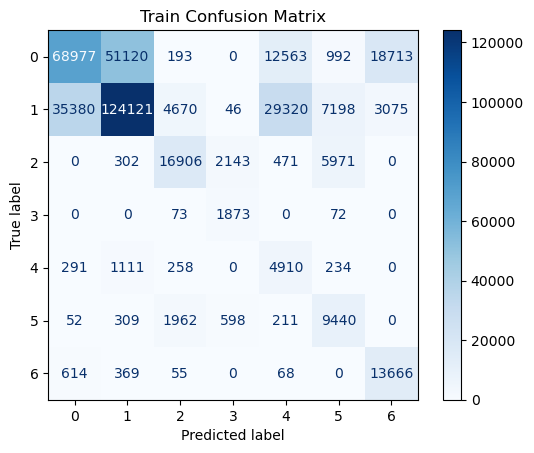

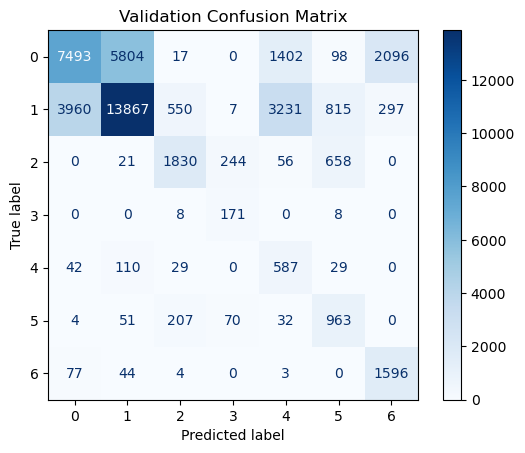

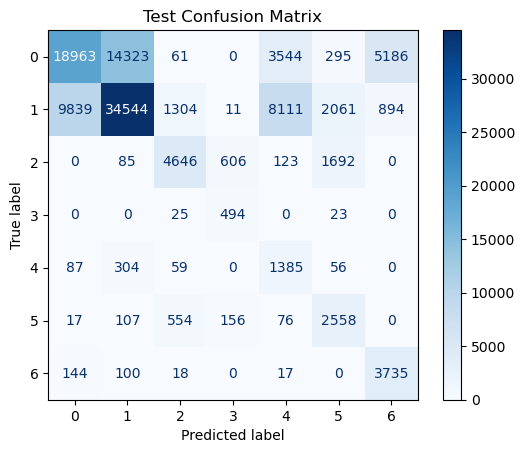

In [17]:
plot_confusion(model, train_loader, "Train Confusion Matrix")
plot_confusion(model, val_loader, "Validation Confusion Matrix")
plot_confusion(model, test_loader, "Test Confusion Matrix")

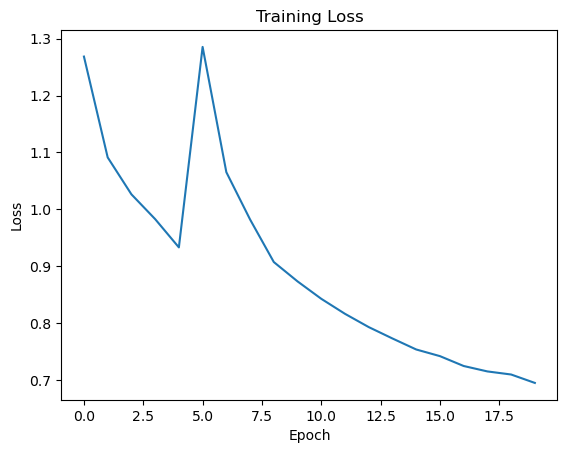

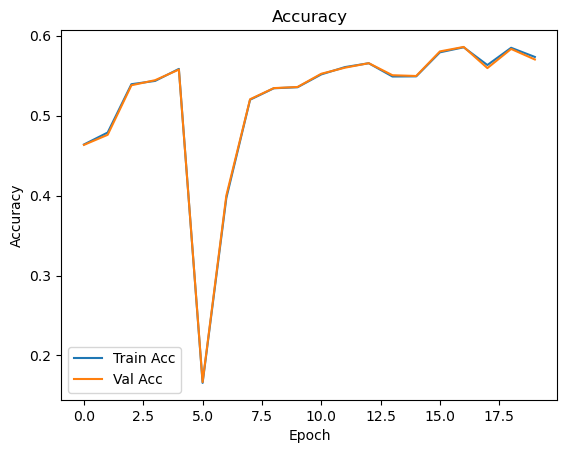

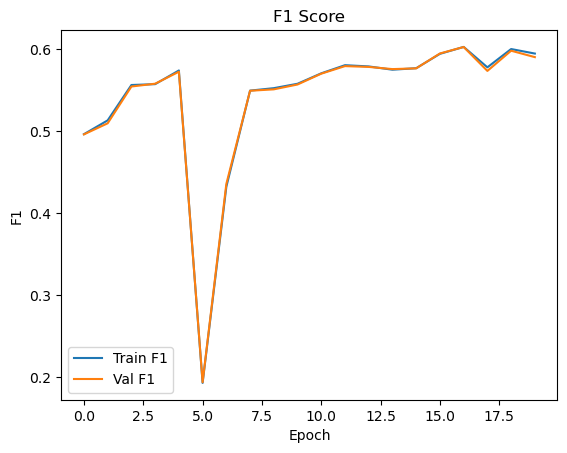

In [18]:
plt.figure()
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.figure()
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure()
plt.plot(train_f1s, label="Train F1")
plt.plot(val_f1s, label="Val F1")
plt.title("F1 Score")
plt.xlabel("Epoch")
plt.ylabel("F1")
plt.legend()
plt.show()